In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the combined dataset we saved in Week 2
df = pd.read_csv('combined_dataset.csv')

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nLabel counts:")
print(df[' Label'].value_counts())

Dataset loaded!
Shape: (975827, 79)

Label counts:
 Label
BENIGN         961992
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64


In [2]:
# Remove negative flow durations
df = df[df[' Flow Duration'] >= 0]

# Replace infinity values
df = df.replace([np.inf, -np.inf], np.nan)

# Drop NaN rows
df = df.dropna()

print("Cleaned! Remaining rows:", df.shape[0])

Cleaned! Remaining rows: 975094


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df[' Label'] = le.fit_transform(df[' Label'])

print("Labels encoded!")
print(df[' Label'].value_counts())
print("\nMapping:")
for i, label in enumerate(le.classes_):
    print(f"{label} → {i}")

Labels encoded!
 Label
0    961262
1      7935
2      5897
Name: count, dtype: int64

Mapping:
BENIGN → 0
FTP-Patator → 1
SSH-Patator → 2


In [4]:
from sklearn.ensemble import RandomForestClassifier

# Separate features and labels
X = df.drop(' Label', axis=1)
y = df[' Label']

# Use a small sample for speed (feature importance doesn't need all data)
X_sample = X.sample(50000, random_state=42)
y_sample = y[X_sample.index]

# Train a quick Random Forest to find important features
print("Finding important features... (this may take 1-2 minutes)")
rf = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 15 most important features:")
print(importances.head(15))

Finding important features... (this may take 1-2 minutes)

Top 15 most important features:
 Destination Port              0.304934
 Bwd Header Length             0.069677
 Total Fwd Packets             0.058452
 Fwd Packet Length Mean        0.055727
Total Length of Fwd Packets    0.050790
 Init_Win_bytes_backward       0.048138
 Fwd Packet Length Max         0.036000
Init_Win_bytes_forward         0.031028
 Fwd Header Length.1           0.025978
 Max Packet Length             0.023944
Fwd PSH Flags                  0.023725
 Bwd Packet Length Mean        0.023637
 Flow Packets/s                0.023069
 SYN Flag Count                0.022329
 Subflow Fwd Bytes             0.022157
dtype: float64


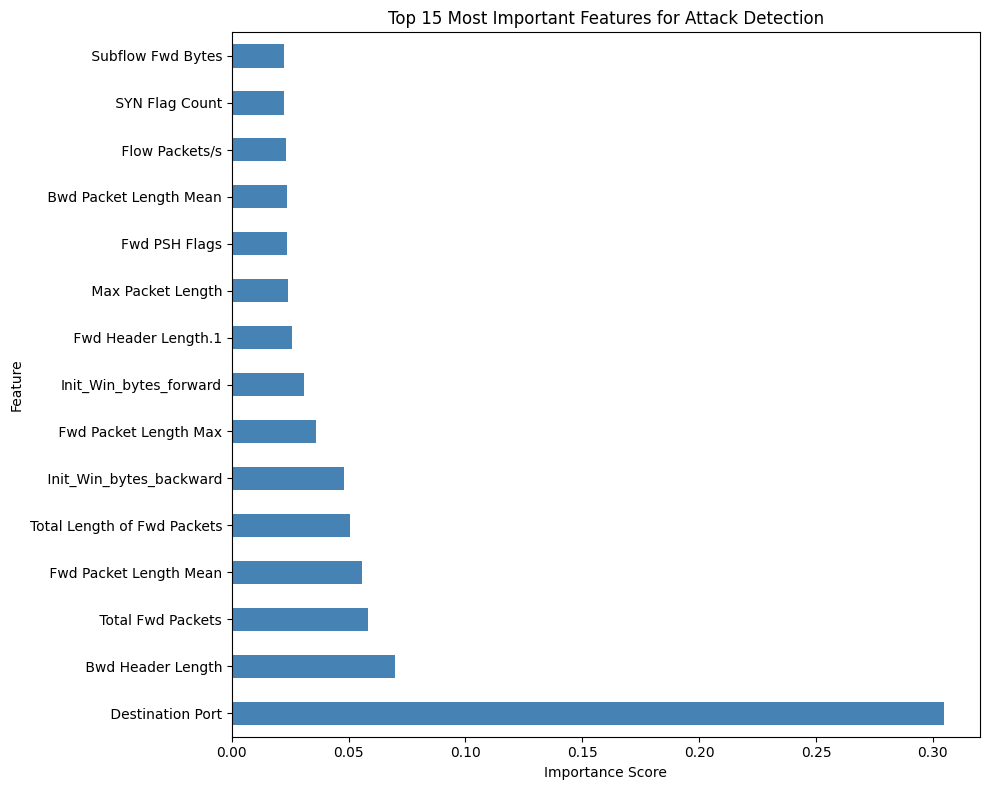

In [5]:
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features for Attack Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [6]:
# Select top 20 features
top_20_features = importances.head(20).index.tolist()

print("Top 20 selected features:")
for i, f in enumerate(top_20_features, 1):
    print(f"{i}. {f}")

# Create new dataset with only top 20 features + label
X_selected = df[top_20_features]
y = df[' Label']

print("\nNew dataset shape:", X_selected.shape)

Top 20 selected features:
1.  Destination Port
2.  Bwd Header Length
3.  Total Fwd Packets
4.  Fwd Packet Length Mean
5. Total Length of Fwd Packets
6.  Init_Win_bytes_backward
7.  Fwd Packet Length Max
8. Init_Win_bytes_forward
9.  Fwd Header Length.1
10.  Max Packet Length
11. Fwd PSH Flags
12.  Bwd Packet Length Mean
13.  Flow Packets/s
14.  SYN Flag Count
15.  Subflow Fwd Bytes
16.  Bwd Packet Length Std
17.  Subflow Bwd Packets
18.  Bwd Packets/s
19.  Idle Min
20.  Flow IAT Std

New dataset shape: (975094, 20)


In [7]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(pd.Series(y).value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_selected, y)

print("\nAfter SMOTE:")
print(pd.Series(y_balanced).value_counts())

Before SMOTE:
 Label
0    961262
1      7935
2      5897
Name: count, dtype: int64

After SMOTE:
 Label
0    961262
1    961262
2    961262
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

print("Scaling done!")
print("Final dataset shape:", X_scaled.shape)

Scaling done!
Final dataset shape: (2883786, 20)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_balanced, 
    test_size=0.2, 
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2307028, 20)
Testing set: (576758, 20)


In [11]:
# Compare average feature values across attack types
df_selected = X_selected.copy()
df_selected['Label'] = y.values

print("Average feature values by traffic type:\n")
print(df_selected.groupby('Label')[[
    ' Destination Port',
    ' Total Fwd Packets', 
    ' Flow Packets/s',
    ' SYN Flag Count'
]].mean().round(2))

Average feature values by traffic type:

       Destination Port  Total Fwd Packets  Flow Packets/s  SYN Flag Count
Label                                                                     
0               9965.80              11.09        62962.18            0.06
1                 21.01               5.50       115888.89            0.50
2                 22.00              11.12        15435.24            0.00


In [12]:
import numpy as np

# Save balanced and scaled data
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

# Save feature names for later
pd.Series(top_20_features).to_csv('top_features.csv', index=False)

print("All files saved successfully!")
print("Saved:")
print("  X_train.npy — Training features")
print("  X_test.npy  — Testing features")
print("  y_train.npy — Training labels")
print("  y_test.npy  — Testing labels")
print("  top_features.csv — Top 20 feature names")

All files saved successfully!
Saved:
  X_train.npy — Training features
  X_test.npy  — Testing features
  y_train.npy — Training labels
  y_test.npy  — Testing labels
  top_features.csv — Top 20 feature names


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the combined dataset we saved in Week 2
df = pd.read_csv('combined_dataset.csv')

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nLabel counts:")
print(df[' Label'].value_counts())

Dataset loaded!
Shape: (975827, 79)

Label counts:
 Label
BENIGN         961992
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64


In [14]:
le = LabelEncoder()
df[' Label'] = le.fit_transform(df[' Label'])

In [15]:
print(df[' Label'].value_counts())
print("\nMapping:")
for i, label in enumerate(le.classes_):
    print(f"{label} → {i}")

 Label
0    961992
1      7938
2      5897
Name: count, dtype: int64

Mapping:
BENIGN → 0
FTP-Patator → 1
SSH-Patator → 2
